                        # Мини-проект по Python                                    Жатько Марина Петровна

In [56]:
import pandas as pd
import numpy as np

import statistics as st
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

#### Проект
Наша кампания ранне имела всего один продукт, он был запущен давно. У нас есть записи сколько выручки нам приносил этот продукт за каждый день его работы. Пару месяцев назад кампания запустила второй продукт, и так же ежедневно фиксировала выручку которую он нам приносил. Данные по выручкам сохранены ниже в переменных product1 и product2.<br>
Наша задача сделать полный анализ на основе всего лишь этих двух списках.

In [57]:
### для загрузки данных
with open(r'project.txt', 'r') as fp:
    for i, line in enumerate(fp):
        if i == 0:
            product1 = [int(i) for i in line.split(' ')]
        if i == 1:
            product2 = [int(i) for i in line.split(' ')]

fp.close()

In [58]:
print(*product1[:30])

196 218 198 223 165 182 257 214 197 251 194 198 203 254 188 230 220 129 181 261 237 196 211 191 268 146 182 231 196 219


In [59]:
print(*product2[:30])

227 201 211 166 170 203 176 155 223 165 198 191 191 185 204 224 170 241 232 170 224 159 222 216 150 175 177 168 212 176


**Задача 1**<br>
подсчитайте среднее арифметическое (mean), медиану и моду для обоих списков: product1 и product2

In [60]:
print("Product 1")
print("Mean:", st.mean(product1))
print("Median:", st.median(product1))
print("Mode:", st.multimode(product1))

print("\nProduct 2")
print("Mean:", st.mean(product2))
print("Median:", st.median(product2))
print("Mode:", st.multimode(product2))

Product 1
Mean: 199.103
Median: 198.5
Mode: [186]

Product 2
Mean: 193.5
Median: 194.5
Mode: [227, 170, 232, 146]


Какая из трех метрик будет наименее показательной, и почему?<br>
На основе оставшихся двух метрик какой продукт в среднем приносит больше выручки?

In [ ]:
1) Наименее показательная метрика — мода. Она зависит от случайного совпадения чисел, а не от общей структуры данных. Для Product 1 модой является 
одно число, для Product 2 - 4 числа. То есть она нестабильна и плохо отражает “типичный день”, поэтому для анализа выручки почти не используется.
2) Среднее (mean): Product 1 > Product 2
   Медиана (median): Product 1 > Product 2
Product 1 в среднем приносит больше выручки, потому что он превосходит Product 2 по обеим устойчивым метрикам — и среднему, и медиане.

**Задача 2**<br>
подсчитайте стандартное отклонение и скажите оценка какого продукта является более точной?

In [61]:
st.stdev(product1), st.stdev(product2)

(28.808372278095014, 29.738082240681482)

**Задача 3**<br>
Нарисуйте распределение вероятности выручки для продукта1 и для продукта2.<br>
Можете использовать гистограмму или kdeplot

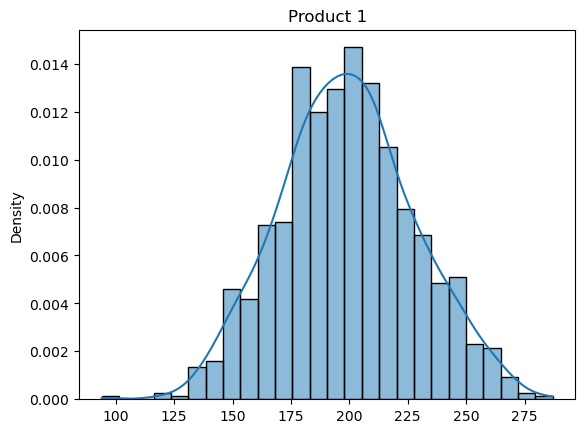

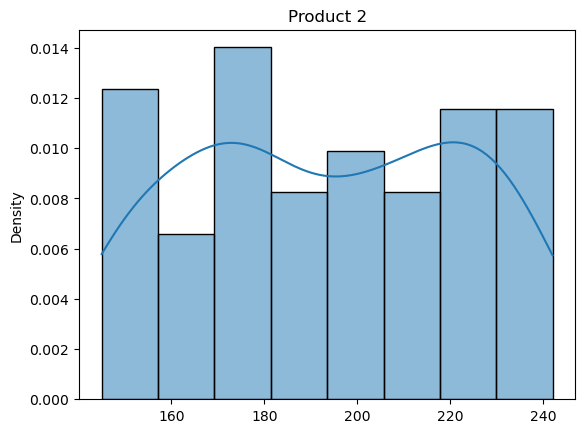

In [62]:
plt.figure()
sns.histplot(product1, kde=True, stat="density")
plt.title("Product 1")
plt.show()

plt.figure()
sns.histplot(product2, kde=True, stat="density")
plt.title("Product 2")
plt.show()

**Задача 4**<br>
Посчитайте размах выручки для продукта1 и для продукта2<br>
Сходится ли разница в размахах и разница в стандартных отклонениях, какая может быть причина?

In [63]:
def stats(x):
    range_val = np.max(x) - np.min(x)
    std_val = np.std(x, ddof=1)  # выборочное стандартное отклонение
    return range_val, std_val

range1, std1 = stats(product1)
range2, std2 = stats(product2)

print("Product 1:")
print(f"Размах: {range1}")
print(f"Стд. отклонение: {std1}")

print("\nProduct 2:")
print(f"Размах: {range2}")
print(f"Стд. отклонение: {std2}")

print("\nСравнение:")
print(f"Размах больше у: {'Product 1' if range1 > range2 else 'Product 2'}")
print(f"Стд. отклонение больше у: {'Product 1' if std1 > std2 else 'Product 2'}")

Product 1:
Размах: 193
Стд. отклонение: 28.808372278095014

Product 2:
Размах: 97
Стд. отклонение: 29.738082240681482

Сравнение:
Размах больше у: Product 1
Стд. отклонение больше у: Product 2


In [ ]:
у Product 1 есть более экстремальные значения
у Product 2 — более равномерный общий разброс

**Задача 5**<br>
Посчитайте межквартильный разммах IQR для продукта1 и продукта2<br>
Теперь убрав выбросы что мы можем сказать о разбросе данных?

In [64]:
product1 = np.array(product1)
product2 = np.array(product2)

def iqr_analysis(x):
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    no_outliers = x[(x >= lower_bound) & (x <= upper_bound)]
    
    return q1, q3, iqr, lower_bound, upper_bound, no_outliers

# анализ
q1_1, q3_1, iqr1, lb1, ub1, clean1 = iqr_analysis(product1)
q1_2, q3_2, iqr2, lb2, ub2, clean2 = iqr_analysis(product2)

print("Product 1 IQR:", iqr1)
print("Product 2 IQR:", iqr2)

print("\nПосле удаления выбросов:")
print("Product 1 std:", np.std(clean1, ddof=1))
print("Product 2 std:", np.std(clean2, ddof=1))

Product 1 IQR: 38.25
Product 2 IQR: 51.0

После удаления выбросов:
Product 1 std: 28.314081624160302
Product 2 std: 29.738082240681482


In [ ]:
После удаления выбросов:
Product 1: есть редкие экстремальные значения, но основная масса данных более компактная, поэтому: IQR меньше, std снизился.
То есть стабильный продукт, но с редкими резкими скачками выручки.

Product 2: нет сильных выбросов, но значения более равномерно распределены внутри диапазона, поэтому:IQR больше, std не изменился
То есть более “ровный” продукт, но с большей внутренней вариативностью

**Задача 6**<br>
Нарисуйте box-plot для продукта1 и с рисунка скажите при каких значениях начинаются выбросы

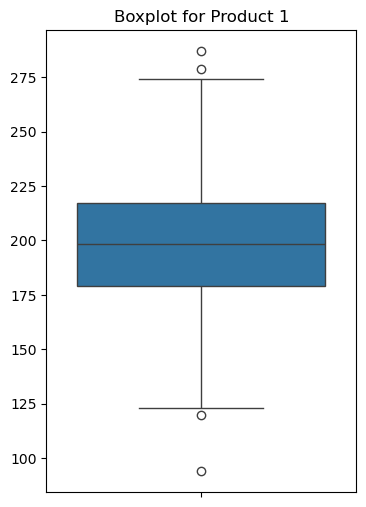

In [65]:
plt.figure(figsize=(4, 6))
sns.boxplot(y=product1)

plt.title("Boxplot for Product 1")
plt.show()

In [ ]:
Выбросы для Product 1 начинаются ниже ~123 и выше ~275 по критерию 1.5 IQR.

**Задача 7**<br>
Нарисуйте QQ plot выручки для обоих продуктов<br>
Какое из распределений является нормальным?

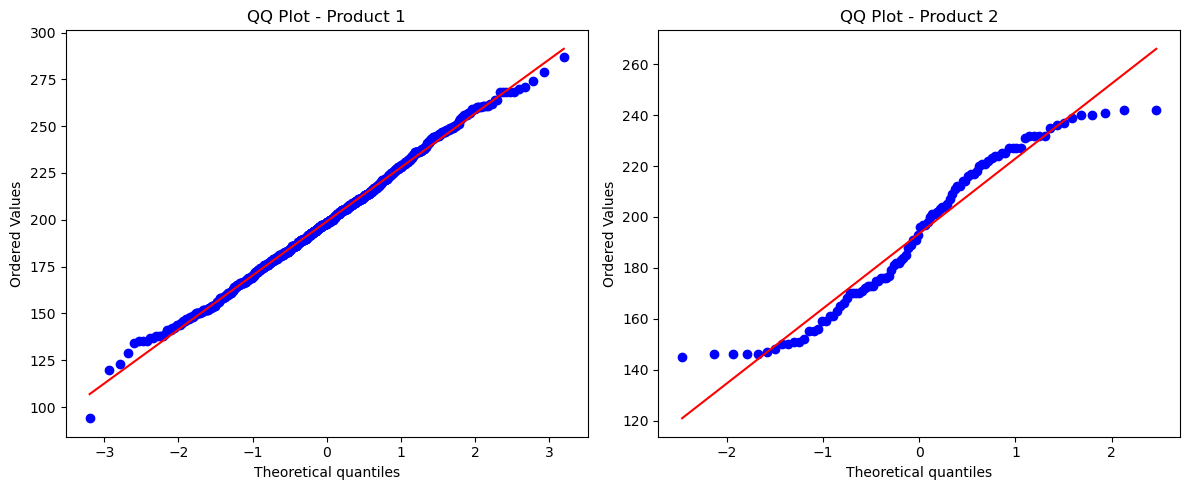

In [66]:
import scipy.stats as stats
plt.figure(figsize=(12, 5))

# QQ plot Product 1
plt.subplot(1, 2, 1)
stats.probplot(product1, dist="norm", plot=plt)
plt.title("QQ Plot - Product 1")

# QQ plot Product 2
plt.subplot(1, 2, 2)
stats.probplot(product2, dist="norm", plot=plt)
plt.title("QQ Plot - Product 2")

plt.tight_layout()
plt.show()

In [ ]:
Product 1 — почти прямая линия, точки хорошо лежат на диагонали, небольшие отклонения только на концах.
Product 1 можно считать нормальным распределением.

Product 2 — имее S-образные изгибы и систематическое отклонение от прямой
Product 2 не является нормальным распределением.

Каких значений много или наоборот не достает в продукте2 чтобы значения стали нормально распределенными?

In [ ]:
Product2-распределение. Провисания точек на QQ-plot показывают локальные отклонения распределения от нормального: если точки ниже линии, в данном 
диапазоне наблюдается недостаток больших значений, если выше — недостаток малых значений. Систематические провисания в хвостах указывают на отличие
формы хвостов распределения от нормального. 
Чтобы стало ближе к нормальному распределению, нужно добавить больше крайних значений:
немного больше низких продаж (≈150 и ниже), немного больше высоких продаж (≈240+)

**Задача 8**<br>
И так мы знаем что выручка продукта1 является нормально распредленной, переведите все значения в стандартное нормальное распределение используя текущие mean и std<br>
создайте новую переменнуя и запишите новые значения туда

In [67]:
mean1 = np.mean(product1)
std1 = np.std(product1, ddof=1)

product1_z = (product1 - mean1) / std1
print(product1_z[:10]) 

[-0.10771174  0.65595514 -0.03828748  0.8295158  -1.18378781 -0.59368158
  2.00972826  0.51710662 -0.07299961  1.80145548]


Нарисуйте kdeplot нового стандартного распределения

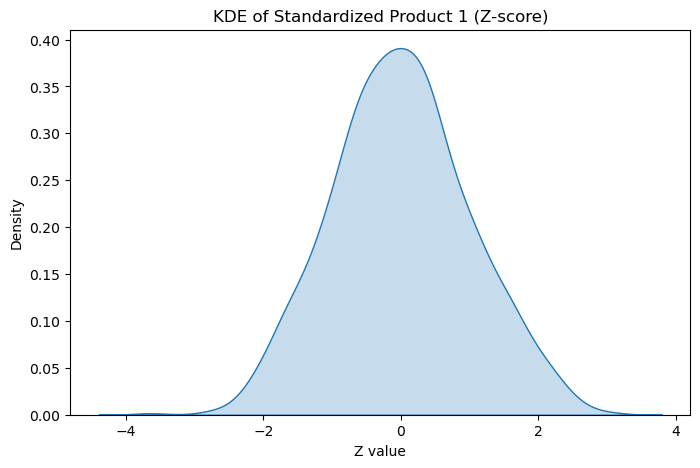

In [68]:
plt.figure(figsize=(8,5))
sns.kdeplot(product1_z, fill=True)

plt.title("KDE of Standardized Product 1 (Z-score)")
plt.xlabel("Z value")
plt.ylabel("Density")
plt.show()

**Задача 9**<br>
Подсчитайте точку слева от которой будет 1% всей вероятности распределения

In [69]:
q01_z = np.percentile(product1_z, 1)
print(q01_z)

-2.1213624778956506


Первое значение в списке product1 равно 94. Когда мы преобразуем список в стандартное нормальное распределение, 94 преобразуется в -3.65<br>
Что нам говорит это число, особенно при сравнении с точкой которую мы только что подсчитали?

In [ ]:
Значение 94 соответствует z-score ≈ -3.65. Это значение лежит значительно левее 1% квантиля нормального распределения (≈ -2.33σ), что указывает 
на его экстремальный характер и классифицирует его как сильный выброс.

**Задача 10**<br>
Продукт2 новый, но уже достаточно стабилизирвался за эти месяцы. Мы хотим знать сколько он будет в среднем нам приносить ежедневно выручки и в будущем.<br>
Дайте точечную оценку средней выручке продукта2

In [70]:
mean_product2 = np.mean(product2)
print("Точечная оценка средней выручки Product 2:", mean_product2)

Точечная оценка средней выручки Product 2: 193.5


Подсчитайте 95% доверительный интервал

In [71]:
n = len(product2)
std2 = np.std(product2, ddof=1)

t_crit = stats.t.ppf(0.975, df=n-1)

margin = t_crit * std2 / np.sqrt(n)

ci_lower = mean_product2 - margin
ci_upper = mean_product2 + margin

print("Среднее:", mean_product2)
print("95% CI:", {ci_lower, ci_upper})

Среднее: 193.5
95% CI: {np.float64(187.59931931126806), np.float64(199.40068068873194)}


**Задача11**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 выше чем 197.5

In [72]:
mu0 = 197.5
t_stat, p_value_two_sided = stats.ttest_1samp(product1, mu0)
p_value_one_sided = p_value_two_sided / 2

print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_one_sided)

alpha = 0.05

if (t_stat > 0) and (p_value_one_sided < alpha):
    print("Вывод: отвергаем H0 → средняя выручка > 197.5")
else:
    print("Вывод: нет оснований отвергнуть H0")

t-statistic: 1.7596034376105127
one-sided p-value: 0.039390559624344984
Вывод: отвергаем H0 → средняя выручка > 197.5


Какой это был типа АБ теста?

In [ ]:
односторонний t-test (one-tail t-test) - выборка vs значение

**Задача12**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 и у продукта2 равны

In [74]:
t_stat, p_value = stats.ttest_ind(product1, product2, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Вывод: отвергаем H0 → средние различаются")
else:
    print("Вывод: нет оснований отвергнуть H0 → средние равны")

t-statistic: 1.8014812850572308
p-value: 0.07417305124776177
Вывод: нет оснований отвергнуть H0 → средние равны
